Usable runs: 180


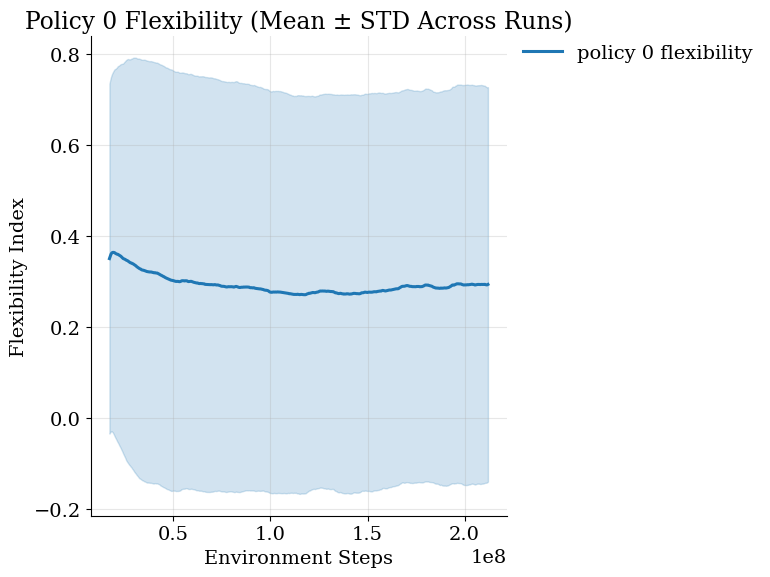

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

policy = 0
metric = f"{policy}/custom/flexibility"
step_col = f"{policy}/global_step"

runs = api.runs(project)

plt.rcParams.update({
    "font.size": 14, "font.family": "serif", "figure.figsize": (10, 6),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 2.2, "savefig.dpi": 300
})

fig, ax = plt.subplots()

def resample_run(df, step_col, metric, num_points=500):
    df = df[[step_col, metric]].dropna()
    steps = np.linspace(df[step_col].min(), df[step_col].max(), num_points)
    values = np.interp(steps, df[step_col], df[metric])
    return steps, values

resampled = []
steps = None

for run in runs:
    df = run.history(keys=[metric, step_col])
    if len(df) < 10:
        continue
    s, values = resample_run(df, step_col, metric)
    resampled.append(values)
    steps = s

print(f"Usable runs: {len(resampled)}")

if resampled:
    resampled = np.array(resampled)
    mean = resampled.mean(axis=0)
    std = resampled.std(axis=0)

    ax.plot(steps, mean, color="tab:blue", label=f"policy {policy} flexibility")
    ax.fill_between(steps, mean - std, mean + std, color="tab:blue", alpha=0.20)

ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_title(f"Policy {policy} Flexibility (Mean ± STD Across Runs)")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Flexibility Index")

plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

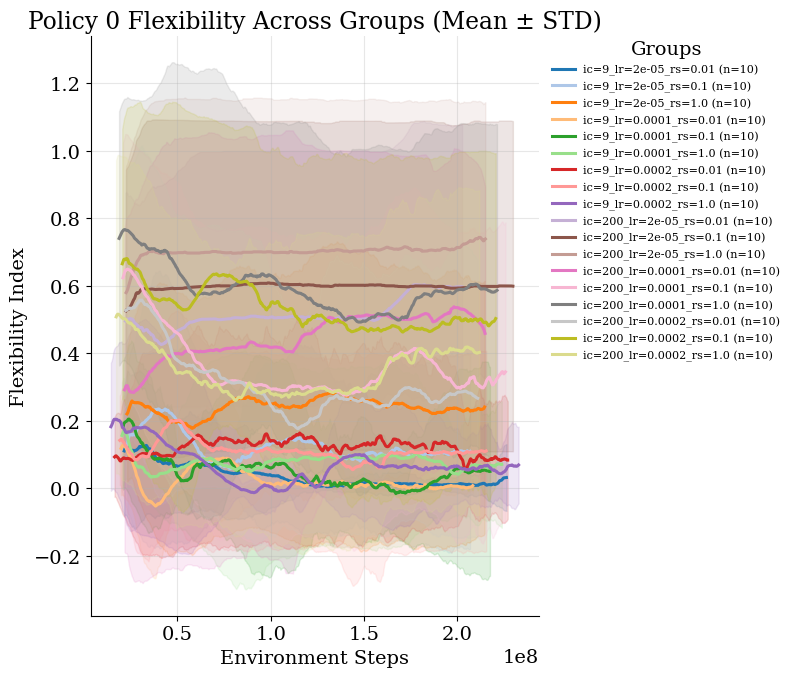

In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

policy = 0
metric = f"{policy}/custom/flexibility"
step_col = f"{policy}/global_step"

all_runs = api.runs(project)

records = []
for run in all_runs:
    records.append({
        "run": run, "run_id": run.id, "name": run.name,
        "number_instruction_coef": run.config.get("number_instruction_coef"),
        "learning_rate": run.config.get("learning_rate"),
        "reward_scale": run.config.get("reward_scale"),
        "INSTR_modulation": run.config.get("INSTR_modulation"),
    })

meta_df = pd.DataFrame(records)

instr_coeffs = sorted(meta_df["number_instruction_coef"].dropna().unique().tolist())
learning_rates = sorted(meta_df["learning_rate"].dropna().unique().tolist())
reward_scales = sorted(meta_df["reward_scale"].dropna().unique().tolist())

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab20.colors

def resample_run(df, step_col, metric, num_points=500):
    df = df[[step_col, metric]].dropna()
    if df[step_col].nunique() < 2:
        return None, None
    steps = np.linspace(df[step_col].min(), df[step_col].max(), num_points)
    values = np.interp(steps, df[step_col], df[metric])
    return steps, values

group_combos = list(product(instr_coeffs, learning_rates, reward_scales))

for gi, (ic, lr, rs) in enumerate(group_combos):
    color = colors[gi % len(colors)]
    group_label = f"ic={ic}_lr={lr}_rs={rs}"

    group_rows = meta_df[
        (meta_df["number_instruction_coef"] == ic) &
        (meta_df["learning_rate"] == lr) &
        (meta_df["reward_scale"] == rs)
    ]

    resampled, steps = [], None
    for _, row in group_rows.iterrows():
        df = row["run"].history(keys=[metric, step_col])
        if len(df) < 10:
            continue
        s, values = resample_run(df, step_col, metric)
        if s is None:
            continue
        resampled.append(values)
        steps = s

    if not resampled:
        print(f"No usable runs for group {group_label} (found {len(group_rows)} runs)")
        continue

    resampled = np.array(resampled)
    mean, std = resampled.mean(axis=0), resampled.std(axis=0)
    ax.plot(steps, mean, color=color, label=f"{group_label} (n={len(resampled)})")
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15)

ax.legend(title="Groups", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
ax.set_title(f"Policy {policy} Flexibility Across Groups (Mean ± STD)")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Flexibility Index")
plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.show()

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

api = wandb.Api()
project = "xiaoxionglin-bernstein-center-freiburg/NEWymaze_norew_instr"

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/fr/fr_ze12/.netrc.


In [2]:
all_runs = api.runs(project)
print(f"Total runs found: {len(all_runs)}")

records = []
for run in all_runs:
    records.append({"run": run, "run_id": run.id, "name": run.name, **run.config})

meta_df = pd.DataFrame(records)
print(meta_df.columns.tolist())

Total runs found: 180
['run', 'run_id', 'name', 'env', 'algo', 'help', 'seed', 'DG_lr', 'gamma', 'res_h', 'res_w', 'device', 'DG_name', 'Hippo_L', 'Hippo_R', 'rollout', 'use_jit', 'use_rnn', 'adam_eps', 'async_rl', 'cli_args', 'git_hash', 'rnn_size', 'rnn_type', 'vtrace_c', 'with_pbt', 'DG_detect', 'benchmark', 'core_name', 'obs_scale', 'optimizer', 'stats_avg', 'train_dir', 'wandb_dir', 'DG_batch_q', 'DG_novelty', 'DG_softmax', 'adam_beta1', 'adam_beta2', 'batch_size', 'dmlab_gpus', 'experiment', 'gae_lambda', 'num_epochs', 'recurrence', 'refractory', 'vtrace_rho', 'wandb_tags', 'wandb_user', 'with_wandb', 'log_to_file', 'lr_schedule', 'num_workers', 'reward_clip', 'serial_mode', 'wandb_group', 'with_vtrace', 'command_line', 'decoder_type', 'depth_sensor', 'double_value', 'encoder_name', 'head_l1_coef', 'nonlinearity', 'num_policies', 'pixel_format', 'reset_critic', 'reward_input', 'reward_scale', 'with_pos_obs', 'env_frameskip', 'git_repo_name', 'kl_loss_coeff', 'learning_rate', 'max

In [3]:
records = []
for run in all_runs:
    records.append({
        "run": run,
        "run_id": run.id,
        "name": run.name,
        "number_instruction_coef": run.config.get("number_instruction_coef"),
        "learning_rate": run.config.get("learning_rate"),
        "reward_scale": run.config.get("reward_scale"),
        "seed": run.config.get("seed"),
        "INSTR_modulation": run.config.get("INSTR_modulation"),
    })

meta_df = pd.DataFrame(records)

print("instr coef values:", sorted(meta_df["number_instruction_coef"].dropna().unique().tolist()))
print("learning_rate values:", sorted(meta_df["learning_rate"].dropna().unique().tolist()))
print("reward_scale values:", sorted(meta_df["reward_scale"].dropna().unique().tolist()))
print("INSTR_modulation values:", sorted(meta_df["INSTR_modulation"].dropna().unique().tolist()))
print(meta_df.groupby(["number_instruction_coef", "learning_rate", "reward_scale", "INSTR_modulation"]).size())

instr coef values: [9, 200]
learning_rate values: [2e-05, 0.0001, 0.0002]
reward_scale values: [0.01, 0.1, 1.0]
INSTR_modulation values: ['multiply', 'sigmoid']
number_instruction_coef  learning_rate  reward_scale  INSTR_modulation
9                        0.00002        0.01          multiply            5
                                                      sigmoid             5
                                        0.10          multiply            5
                                                      sigmoid             5
                                        1.00          multiply            5
                                                      sigmoid             5
                         0.00010        0.01          multiply            5
                                                      sigmoid             5
                                        0.10          multiply            5
                                                      sigmoid             5
        

In [5]:
import os
import wandb
import pandas as pd
import time

#wandb.login(relogin=True, key="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")  # Ensure you're logged in to access the API


instr_coeffs = [9, 200]      # two values of cli_args.number_instruction_coeff
learning_rates = [0.0002, 0.0001, 0.00002]    # three values of cli_args.learning_rate
reward_scales = [1, 0.1, 0.01]     # three values of cli_args.reward_scale
INSTR_modulation = ["sigmoid", "multiply"]  # three values of cli_args.INSTR_modulation

policy = 0
metric = f"{policy}/custom/flexibility"
step_col = f"{policy}/len/len" 

def safe_history(run_id, project, keys, samples=1000, max_retries=5, base_delay=4):
    api_local = wandb.Api(timeout=60)
    for attempt in range(max_retries):
        try:
            run = api_local.run(f"{project}/{run_id}")
            return run.history(keys=keys, samples=samples, pandas=True)
        except Exception as e:
            err_name = type(e).__name__
            if attempt == max_retries - 1:
                print(f"Giving up on run {run_id} after {max_retries} attempts: {err_name}: {e}")
                return pd.DataFrame()
            wait = base_delay * (2 ** attempt)
            print(f"[{err_name}] retry {attempt+1}/{max_retries} for run {run_id} after {wait}s")
            if "Mailbox" in err_name or "CommError" in err_name:
                wandb.teardown()
                time.sleep(2)
                api_local = wandb.Api(timeout=60)
            time.sleep(wait)

cache_dir = "wandb_history_cache"
os.makedirs(cache_dir, exist_ok=True)

metric = f"{policy}/custom/flexibility"
step_col = f"{policy}/len/len"

for i, row in meta_df.iterrows():
    run = row["run"]
    cache_path = os.path.join(cache_dir, f"{run.id}_p{policy}.csv")
    if os.path.exists(cache_path):
        continue
    hist = safe_history(run.id, project, keys=[metric, step_col], samples=300)
    hist.to_csv(cache_path, index=False)
    time.sleep(0.4)
    if (i + 1) % 20 == 0:
        print(f"Cached {i+1}/{len(meta_df)} runs")

Cached 20/180 runs
Cached 40/180 runs
Cached 60/180 runs
Cached 80/180 runs
Cached 100/180 runs
Cached 120/180 runs
Cached 140/180 runs
Cached 160/180 runs
Cached 180/180 runs


In [14]:
row0 = meta_df.iloc[0]
print(row0["run"].config)

{'env': 'ymaze_instr', 'algo': 'APPO', 'help': False, 'seed': 1111, 'DG_lr': None, 'gamma': 0.99, 'res_h': 72, 'res_w': 96, 'device': 'cpu', 'DG_name': 'batchnorm_relu', 'Hippo_L': 64, 'Hippo_R': 8, 'rollout': 64, 'use_jit': True, 'use_rnn': True, 'adam_eps': 1e-06, 'async_rl': True, 'cli_args': {'env': 'ymaze_instr', 'algo': 'APPO', 'seed': 1111, 'gamma': 0.99, 'device': 'cpu', 'DG_name': 'batchnorm_relu', 'Hippo_L': 64, 'rollout': 64, 'use_rnn': True, 'rnn_size': 1148, 'rnn_type': 'gru', 'with_pbt': True, 'benchmark': False, 'core_name': 'BypassSS', 'train_dir': './train_dir/newmod_norew_INSTR/newmod_norew_INSTR_', 'batch_size': 2048, 'experiment': '00_newmod_norew_INSTR_see_1111_n.i.coe_9_r.sca_0.01_l.rat_2e-05', 'num_epochs': 1, 'recurrence': 64, 'wandb_user': 'xiaoxionglin-bernstein-center-freiburg', 'with_wandb': True, 'num_workers': 8, 'depth_sensor': True, 'nonlinearity': 'relu', 'num_policies': 4, 'reward_scale': 0.01, 'env_frameskip': 8, 'learning_rate': 2e-05, 'max_grad_norm

In [12]:
group_combos = list(product(instr_coeffs, learning_rates, reward_scales))
colors = plt.cm.tab20.colors

cache_dir = "wandb_history_cache"  # must match the folder name used when caching

def load_cached_history(run_id, policy):
    path = os.path.join(cache_dir, f"{run_id}_p{policy}.csv")
    if not os.path.exists(path):
        return pd.DataFrame()
    return pd.read_csv(path)

for gi, (ic, lr, rs) in enumerate(group_combos):
    color = colors[gi % len(colors)]
    group_label = f"n.i.coe_{ic}_r.sca_{rs}_l.rat_{lr}"

    group_rows = meta_df[
        (meta_df["number_instruction_coef"] == ic) &
        (meta_df["learning_rate"] == lr) &
        (meta_df["reward_scale"] == rs)
    ]

    resampled, common_steps = [], None
    for _, row in group_rows.iterrows():
        hist = load_cached_history(row["run_id"], policy)
        if hist.empty or len(hist) < 10 or metric not in hist.columns or step_col not in hist.columns:
            continue
        steps, values = resample_run(hist, step_col, metric)
        if steps is None:
            continue
        resampled.append(values)
        common_steps = steps

    if not resampled:
        print(f"No usable runs for group {group_label}")
        continue

    resampled = np.array(resampled)
    mean, std = resampled.mean(axis=0), resampled.std(axis=0)
    ax.plot(common_steps, mean, color=color, label=f"{group_label} (n={len(resampled)})")
    ax.fill_between(common_steps, mean - std, mean + std, color=color, alpha=0.15)

ax.legend(title="Groups", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)
ax.set_title(f"Policy {policy} Flexibility Across Groups (Mean ± STD)")
ax.set_xlabel("Episode Length / Steps")
ax.set_ylabel("Flexibility Index")
plt.tight_layout(rect=[0, 0, 0.75, 1])
#plt.savefig("flexibility_by_group.png", bbox_inches="tight")
plt.show()

EmptyDataError: No columns to parse from file

In [ ]:
cache_dir = "wandb_history_cache"  # must match the folder name used when caching

def load_cached_history(run_id, policy):
    path = os.path.join(cache_dir, f"{run_id}_p{policy}.csv")
    if not os.path.exists(path):
        return pd.DataFrame()
    return pd.read_csv(path)

first_run_id = meta_df.iloc[0]["run_id"]
test_hist = load_cached_history(first_run_id, policy)
print(test_hist.shape)
print(test_hist.head())

EmptyDataError: No columns to parse from file

In [11]:
def load_cached_history(run_id, policy):
    path = os.path.join(cache_dir, f"{run_id}_p{policy}.csv")
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()